In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2
import numpy as np

/Users/kamilchaber/Desktop/CLIP project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


In [16]:
images_path = []
classes = []
all_classes  = []

main_path = "../data/animals"

for path_name, foldernames, filenames in os.walk(main_path):
    for file_name in filenames:
        file_path = os.path.join(path_name, file_name)
        images_path.append(file_path)
        all_classes.append(os.path.basename(path_name))

classes = sorted(set(all_classes))
len(images_path)

print(f"Liczba zdjec w folderach {len(images_path)}")
print(f"Klasy: {len(classes)}")


Liczba zdjec w folderach 5400
Klasy: 90


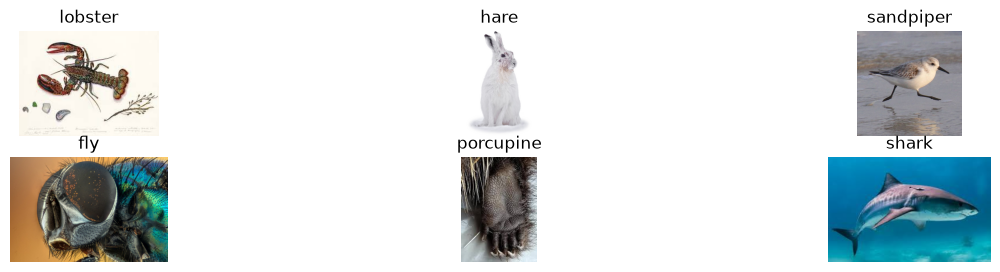

In [13]:
plt.figure(figsize=(15, 3))
for i in range(6):
    plt.subplot(2, 3, i+1)
    image_path = random.choice(images_path)
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(image_path.split("/")[3])
    plt.axis("off")

In [ ]:
from pathlib import Path
class ImageDataset(Dataset):
    def __init__(self, all_images_paths, all_classes_name, transform=None):
        self.images = all_images_paths
        self.classes = all_classes_name

        if transform is not None:
            self.transform = transform
        else:
            self.transform = v2.Compose([
                v2.Resize(256),
                v2.CenterCrop(224),
                v2.RandomHorizontalFlip(),
                v2.RandomRotation(degrees=20),
                v2.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2,
                    hue=0.1
                ),
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

        self.classes_to_ids = {self.classes[i]: i for i in range(len(self.classes))}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        label_name = Path(image_path).parent.name

        try:
            label_num = self.classes_to_ids[label_name]
        except KeyError:
            raise ValueError(f"Unknown class: {label_name}")

        img = Image.open(image_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label_num
